## 1. Configuration et imports

In [1]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration des affichages
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Imports scikit-learn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Import du module de prétraitement (Personne 2)
import sys
sys.path.append('../src')
from preprocessing import (
    load_data,
    preprocess_train,
    create_sklearn_pipeline
)

# Seed pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports réussis!")

✓ Imports réussis!


## 2. Chargement des données

Nous utilisons le pipeline de prétraitement.

In [2]:
# Chargement des données brutes
train_raw, _ = load_data('../data/raw/train.csv')

# Affichage des premières lignes
print("Aperçu des données brutes:")
train_raw.head()

Données chargées:
  - Train: 891 lignes, 12 colonnes
Aperçu des données brutes:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Application du prétraitement complet
train_processed, encoders = preprocess_train(train_raw)

print("\n" + "="*50)
print("Données après prétraitement:")
print("="*50)
train_processed.head()

PRÉTRAITEMENT DES DONNÉES D'ENTRAÎNEMENT

Valeurs manquantes - Avant prétraitement
  Cabin: 687 (77.1%)
  Age: 177 (19.9%)
  Embarked: 2 (0.2%)

Création des features...
  ✓ Title extrait du nom
  ✓ FamilySize, IsAlone, FamilySizeGroup créés
  ✓ HasCabin, Deck créés
  ✓ AgeGroup créé

Imputation des valeurs manquantes...
  Age imputé par médiane selon le titre:
    - Master: 3.5 ans
    - Miss: 21.0 ans
    - Mr: 30.0 ans
    - Mrs: 35.0 ans
    - Rare: 48.5 ans
  Embarked: 2 valeurs imputées avec 'S'
  Fare: aucune valeur manquante

Encodage des variables catégorielles...
  Sex: {'female': 0, 'male': 1}
  Embarked: 2 nouvelles colonnes
  Title: 4 nouvelles colonnes
  FamilySizeGroup: 3 nouvelles colonnes
  Deck: 8 nouvelles colonnes
  AgeGroup: 4 nouvelles colonnes

Colonnes supprimées: ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Title', 'FamilySizeGroup', 'Deck', 'AgeGroup']
Features finales: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Is

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySizeGroup_Large,FamilySizeGroup_Medium,FamilySizeGroup_Small,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_Unknown
0,0,3,1,22.0,1,0,7.2500,2,0,0,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
1,1,1,0,38.0,1,0,71.2833,2,0,1,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
2,1,3,0,26.0,0,0,7.9250,1,1,0,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,1,1,0,35.0,1,0,53.1000,2,0,1,False,True,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
4,0,3,1,35.0,0,0,8.0500,1,1,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [4]:
# Vérification de la forme des données
print(f"Shape des données prétraitées: {train_processed.shape}")
print(f"\nColonnes disponibles:")
print(train_processed.columns.tolist())

Shape des données prétraitées: (891, 31)

Colonnes disponibles:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'FamilySizeGroup_Large', 'FamilySizeGroup_Medium', 'FamilySizeGroup_Small', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'AgeGroup_Child', 'AgeGroup_Senior', 'AgeGroup_Teen', 'AgeGroup_Unknown']


## 3. Séparation des données (Train / Test)

### 3.1 Préparation des features et de la cible

- **X** : Features (toutes les colonnes sauf `Survived`)
- **y** : Variable cible (`Survived`)

In [5]:
# Séparation features / cible
X = train_processed.drop('Survived', axis=1)
y = train_processed['Survived']

print(f"Dimensions de X: {X.shape}")
print(f"Dimensions de y: {y.shape}")
print(f"\nDistribution de la cible:")
print(y.value_counts(normalize=True).round(3))

Dimensions de X: (891, 30)
Dimensions de y: (891,)

Distribution de la cible:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


### 3.2 Split Train/Test stratifié

On utilise `train_test_split` avec:
- `test_size=0.2` : 20% des données pour le test final
- `stratify=y` : Préserve la proportion de survivants dans les deux sets
- `random_state=42` : Pour la reproductibilité

**Important**: Ce test set sera gardé **intouché** jusqu'à l'évaluation finale !

In [6]:
# Split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Important: préserve la distribution de la cible
)

print("="*50)
print("SÉPARATION TRAIN/TEST")
print("="*50)
print(f"\nTaille du train set: {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Taille du test set:  {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

SÉPARATION TRAIN/TEST

Taille du train set: 712 échantillons (80%)
Taille du test set:  179 échantillons (20%)


In [7]:
# Vérification de la stratification
print("Vérification de la stratification (distribution de Survived):")
print(f"  - Dataset complet: {y.mean():.3f}")
print(f"  - Train set:       {y_train.mean():.3f}")
print(f"  - Test set:        {y_test.mean():.3f}")
print("\n✓ Les proportions sont bien conservées!")

Vérification de la stratification (distribution de Survived):
  - Dataset complet: 0.384
  - Train set:       0.383
  - Test set:        0.385

✓ Les proportions sont bien conservées!


## 4. Configuration de la Validation Croisée (K-Fold)

### Pourquoi la validation croisée ?

- Un seul split train/test peut donner des résultats biaisés selon les données choisies
- La validation croisée **divise le train set en k sous-ensembles** (folds)
- Le modèle est entraîné k fois, chaque fois sur k-1 folds et évalué sur le fold restant
- On obtient **k scores** dont on peut calculer la moyenne et l'écart-type

### Configuration

- **k=5** : Bon compromis entre variance et temps de calcul
- **StratifiedKFold** : Préserve la distribution de la cible dans chaque fold

In [8]:
# Configuration de la validation croisée stratifiée
cv_strategy = StratifiedKFold(
    n_splits=5,           # 5 folds
    shuffle=True,         # Mélange les données
    random_state=RANDOM_STATE
)

print("Configuration de la validation croisée:")
print(f"  - Nombre de folds: {cv_strategy.n_splits}")
print(f"  - Type: StratifiedKFold (préserve les proportions)")
print(f"  - Shuffle: True")
print(f"  - Random state: {RANDOM_STATE}")

Configuration de la validation croisée:
  - Nombre de folds: 5
  - Type: StratifiedKFold (préserve les proportions)
  - Shuffle: True
  - Random state: 42


In [9]:
# Visualisation des folds
print("\nDétail des folds:")
print("-" * 50)

for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train), 1):
    train_survived = y_train.iloc[train_idx].mean()
    val_survived = y_train.iloc[val_idx].mean()
    
    print(f"Fold {fold_idx}:")
    print(f"  Train: {len(train_idx)} samples (Survived: {train_survived:.2%})")
    print(f"  Val:   {len(val_idx)} samples (Survived: {val_survived:.2%})")


Détail des folds:
--------------------------------------------------
Fold 1:
  Train: 569 samples (Survived: 38.31%)
  Val:   143 samples (Survived: 38.46%)
Fold 2:
  Train: 569 samples (Survived: 38.31%)
  Val:   143 samples (Survived: 38.46%)
Fold 3:
  Train: 570 samples (Survived: 38.25%)
  Val:   142 samples (Survived: 38.73%)
Fold 4:
  Train: 570 samples (Survived: 38.42%)
  Val:   142 samples (Survived: 38.03%)
Fold 5:
  Train: 570 samples (Survived: 38.42%)
  Val:   142 samples (Survived: 38.03%)


## 5. Fonction d'évaluation avec Validation Croisée

Créons une fonction réutilisable pour évaluer n'importe quel modèle avec plusieurs métriques.

In [10]:
def evaluate_model_cv(model, X, y, cv, model_name="Model"):
    """
    Évalue un modèle avec validation croisée sur plusieurs métriques.
    
    Parameters
    ----------
    model : estimator
        Modèle sklearn à évaluer
    X : array-like
        Features d'entraînement
    y : array-like
        Variable cible
    cv : cross-validation strategy
        Stratégie de validation croisée
    model_name : str
        Nom du modèle pour l'affichage
    
    Returns
    -------
    results : dict
        Dictionnaire contenant les scores moyens et écarts-types
    """
    # Métriques à calculer
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    # Validation croisée avec plusieurs métriques
    cv_results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    # Extraction et formatage des résultats
    results = {
        'model': model_name,
        'accuracy_mean': cv_results['test_accuracy'].mean(),
        'accuracy_std': cv_results['test_accuracy'].std(),
        'precision_mean': cv_results['test_precision'].mean(),
        'precision_std': cv_results['test_precision'].std(),
        'recall_mean': cv_results['test_recall'].mean(),
        'recall_std': cv_results['test_recall'].std(),
        'f1_mean': cv_results['test_f1'].mean(),
        'f1_std': cv_results['test_f1'].std(),
        'roc_auc_mean': cv_results['test_roc_auc'].mean(),
        'roc_auc_std': cv_results['test_roc_auc'].std(),
    }
    
    # Affichage des résultats
    print(f"\n{'='*60}")
    print(f"Résultats pour: {model_name}")
    print('='*60)
    print(f"{'Métrique':<15} {'Moyenne':>10} {'± Écart-type':>15}")
    print('-'*45)
    print(f"{'Accuracy':<15} {results['accuracy_mean']:>10.4f} {'± ' + f'{results["accuracy_std"]:.4f}':>15}")
    print(f"{'Precision':<15} {results['precision_mean']:>10.4f} {'± ' + f'{results["precision_std"]:.4f}':>15}")
    print(f"{'Recall':<15} {results['recall_mean']:>10.4f} {'± ' + f'{results["recall_std"]:.4f}':>15}")
    print(f"{'F1-Score':<15} {results['f1_mean']:>10.4f} {'± ' + f'{results["f1_std"]:.4f}':>15}")
    print(f"{'ROC-AUC':<15} {results['roc_auc_mean']:>10.4f} {'± ' + f'{results["roc_auc_std"]:.4f}':>15}")
    
    return results

print("✓ Fonction d'évaluation définie!")

✓ Fonction d'évaluation définie!


## 6. Test rapide avec un modèle simple

Testons notre setup avec une **Régression Logistique** comme baseline.

In [11]:
# Test avec Régression Logistique (baseline)
baseline_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# Évaluation avec validation croisée
baseline_results = evaluate_model_cv(
    baseline_model,
    X_train, y_train,
    cv=cv_strategy,
    model_name="Logistic Regression (Baseline)"
)


Résultats pour: Logistic Regression (Baseline)
Métrique           Moyenne    ± Écart-type
---------------------------------------------
Accuracy            0.8217        ± 0.0251
Precision           0.7695        ± 0.0505
Recall              0.7694        ± 0.0325
F1-Score            0.7683        ± 0.0295
ROC-AUC             0.8674        ± 0.0192


In [12]:
# Sauvegarde des données pour les prochaines étapes
print("="*50)
print("RÉCAPITULATIF")
print("="*50)
print(f"\nDonnées disponibles pour la modélisation:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test:  {X_test.shape} (gardé intact!)")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test:  {y_test.shape}")
print(f"\nValidation croisée: {cv_strategy.n_splits}-fold stratifié")
print(f"Random state: {RANDOM_STATE}")
print(f"\n✓ Setup prêt pour l'entraînement des modèles!")

RÉCAPITULATIF

Données disponibles pour la modélisation:
  - X_train: (712, 30)
  - X_test:  (179, 30) (gardé intact!)
  - y_train: (712,)
  - y_test:  (179,)

Validation croisée: 5-fold stratifié
Random state: 42

✓ Setup prêt pour l'entraînement des modèles!


---

## 7. Entraînement et Comparaison des Modèles

Nous allons maintenant entraîner et comparer plusieurs algorithmes de classification :

| Modèle | Description | Avantages |
|--------|-------------|-----------|
| **Régression Logistique** | Algorithme linéaire simple | Baseline, interprétable, rapide |
| **Random Forest** | Ensemble d'arbres de décision | Réduit l'overfitting, importance des features |
| **Gradient Boosting** | Arbres séquentiels corrigeant les erreurs | Très performant, gère bien les non-linéarités |
| **SVM (SVC)** | Hyperplan de séparation optimal | Bon après standardisation, marges maximales |

In [13]:
# Définition des modèles à comparer
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,      # Nombre d'arbres
        max_depth=10,          # Profondeur max pour éviter l'overfitting
        min_samples_split=5,   # Minimum d'échantillons pour split
        random_state=RANDOM_STATE,
        n_jobs=-1              # Utilise tous les CPU
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,      # Nombre d'arbres
        learning_rate=0.1,     # Taux d'apprentissage (shrinkage)
        max_depth=3,           # Arbres peu profonds (recommandé pour boosting)
        random_state=RANDOM_STATE
    ),
    
    'SVM (SVC)': SVC(
        kernel='rbf',          # Noyau gaussien
        C=1.0,                 # Régularisation
        probability=True,      # Nécessaire pour ROC-AUC
        random_state=RANDOM_STATE
    )
}

print(f"Modèles à entraîner: {len(models)}")
for name in models.keys():
    print(f"  - {name}")

Modèles à entraîner: 4
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - SVM (SVC)


In [14]:
# Entraînement et évaluation de tous les modèles
all_results = []

print("="*70)
print("ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES")
print("="*70)

for name, model in models.items():
    results = evaluate_model_cv(
        model,
        X_train, y_train,
        cv=cv_strategy,
        model_name=name
    )
    all_results.append(results)

print("\n" + "="*70)
print("✓ Tous les modèles ont été évalués!")
print("="*70)

ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES

Résultats pour: Logistic Regression
Métrique           Moyenne    ± Écart-type
---------------------------------------------
Accuracy            0.8217        ± 0.0251
Precision           0.7695        ± 0.0505
Recall              0.7694        ± 0.0325
F1-Score            0.7683        ± 0.0295
ROC-AUC             0.8674        ± 0.0192

Résultats pour: Random Forest
Métrique           Moyenne    ± Écart-type
---------------------------------------------
Accuracy            0.8301        ± 0.0182
Precision           0.8118        ± 0.0439
Recall              0.7289        ± 0.0184
F1-Score            0.7673        ± 0.0192
ROC-AUC             0.8797        ± 0.0260

Résultats pour: Gradient Boosting
Métrique           Moyenne    ± Écart-type
---------------------------------------------
Accuracy            0.8160        ± 0.0167
Precision           0.7996        ± 0.0472
Recall              0.6997        ± 0.0389
F1-Score            0.7445      

## 8. Tableau Comparatif des Modèles

Comparons les performances de tous les modèles dans un tableau synthétique.

In [15]:
# Création du DataFrame comparatif
comparison_df = pd.DataFrame(all_results)

# Affichage formaté
display_df = pd.DataFrame({
    'Modèle': comparison_df['model'],
    'Accuracy': comparison_df.apply(lambda x: f"{x['accuracy_mean']:.4f} ± {x['accuracy_std']:.4f}", axis=1),
    'Precision': comparison_df.apply(lambda x: f"{x['precision_mean']:.4f} ± {x['precision_std']:.4f}", axis=1),
    'Recall': comparison_df.apply(lambda x: f"{x['recall_mean']:.4f} ± {x['recall_std']:.4f}", axis=1),
    'F1-Score': comparison_df.apply(lambda x: f"{x['f1_mean']:.4f} ± {x['f1_std']:.4f}", axis=1),
    'ROC-AUC': comparison_df.apply(lambda x: f"{x['roc_auc_mean']:.4f} ± {x['roc_auc_std']:.4f}", axis=1),
})

print("="*90)
print("TABLEAU COMPARATIF DES MODÈLES (Validation Croisée 5-Fold)")
print("="*90)
display_df.set_index('Modèle')

TABLEAU COMPARATIF DES MODÈLES (Validation Croisée 5-Fold)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.8217 ± 0.0251,0.7695 ± 0.0505,0.7694 ± 0.0325,0.7683 ± 0.0295,0.8674 ± 0.0192
Random Forest,0.8301 ± 0.0182,0.8118 ± 0.0439,0.7289 ± 0.0184,0.7673 ± 0.0192,0.8797 ± 0.0260
Gradient Boosting,0.8160 ± 0.0167,0.7996 ± 0.0472,0.6997 ± 0.0389,0.7445 ± 0.0215,0.8923 ± 0.0155
SVM (SVC),0.6910 ± 0.0184,0.7083 ± 0.0281,0.3298 ± 0.0565,0.4475 ± 0.0546,0.7587 ± 0.0174


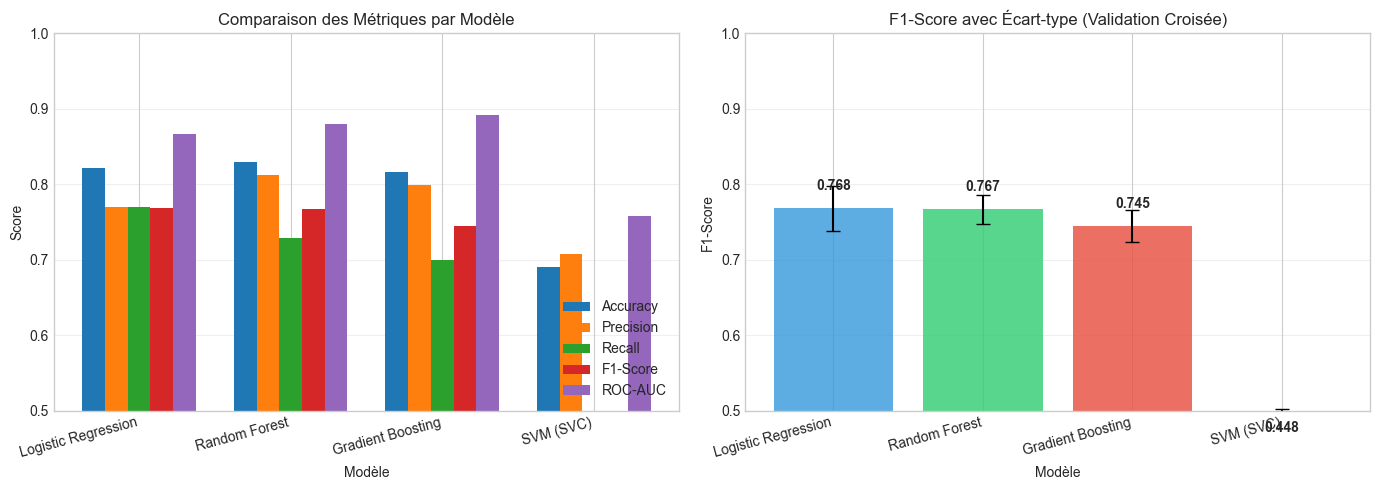


✓ Figure sauvegardée: reports/figures/model_comparison.png


In [16]:
# Visualisation des scores moyens
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Comparaison des métriques
metrics = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(comparison_df))
width = 0.15

for i, (metric, name) in enumerate(zip(metrics, metric_names)):
    axes[0].bar(x + i*width, comparison_df[metric], width, label=name)

axes[0].set_xlabel('Modèle')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des Métriques par Modèle')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(comparison_df['model'], rotation=15, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: F1-Score avec barres d'erreur
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = axes[1].bar(comparison_df['model'], comparison_df['f1_mean'], 
                   yerr=comparison_df['f1_std'], capsize=5, color=colors, alpha=0.8)
axes[1].set_xlabel('Modèle')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score avec Écart-type (Validation Croisée)')
axes[1].set_xticklabels(comparison_df['model'], rotation=15, ha='right')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, comparison_df['f1_mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardée: reports/figures/model_comparison.png")

## 9. Courbes ROC

La courbe ROC (Receiver Operating Characteristic) permet de visualiser la capacité discriminante de chaque modèle. L'aire sous la courbe (AUC) mesure cette capacité :
- **AUC = 0.5** : Modèle aléatoire (pas mieux que le hasard)
- **AUC = 1.0** : Modèle parfait

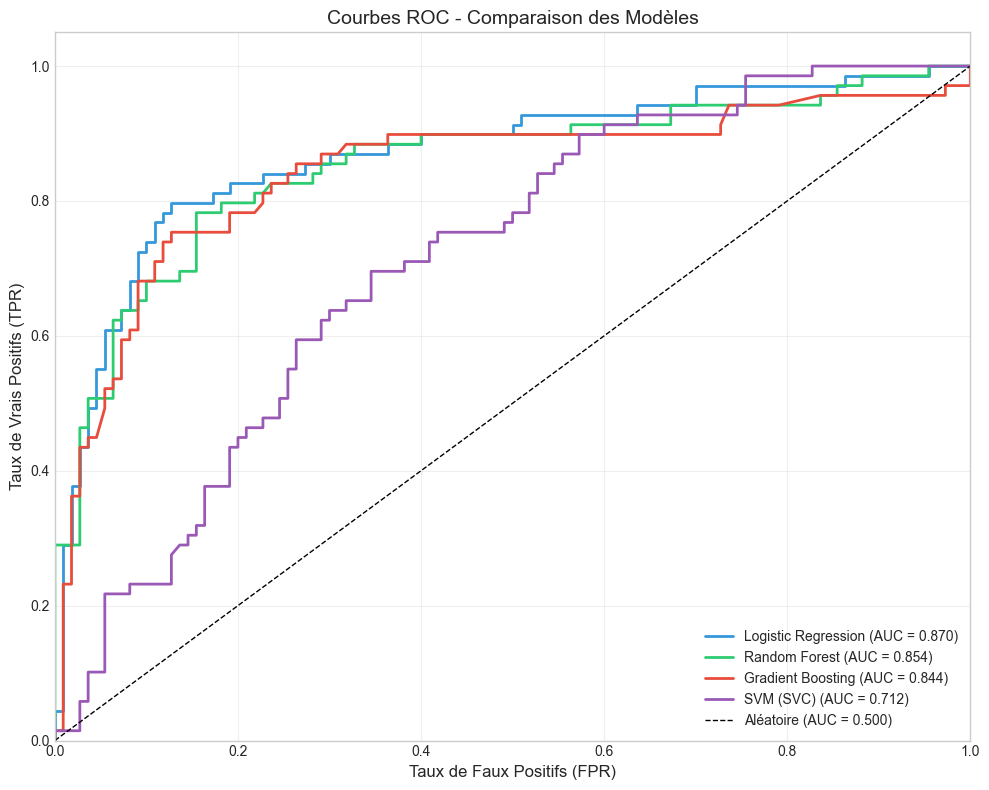


✓ Figure sauvegardée: reports/figures/roc_curves.png


In [17]:
# Courbes ROC pour tous les modèles
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, model), color in zip(models.items(), colors):
    # Entraîner le modèle sur tout le train set
    model.fit(X_train, y_train)
    
    # Prédictions de probabilité sur le test set
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test)
    
    # Calcul de la courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Tracer la courbe
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{name} (AUC = {roc_auc:.3f})')

# Ligne de référence (modèle aléatoire)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des Modèles', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardée: reports/figures/roc_curves.png")

## 10. Évaluation Finale sur le Test Set

Maintenant que nous avons comparé les modèles avec la validation croisée, évaluons-les sur le **test set** qui a été mis de côté.

In [18]:
# Évaluation sur le test set
print("="*70)
print("ÉVALUATION FINALE SUR LE TEST SET")
print("="*70)

test_results = []

for name, model in models.items():
    # Le modèle a déjà été entraîné sur X_train dans la cellule précédente
    # Prédictions
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test)
    
    # Calcul des métriques
    results = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    test_results.append(results)
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  F1-Score:  {results['f1']:.4f}")
    print(f"  ROC-AUC:   {results['roc_auc']:.4f}")

test_results_df = pd.DataFrame(test_results)

ÉVALUATION FINALE SUR LE TEST SET

Logistic Regression:
  Accuracy:  0.8436
  Precision: 0.8060
  Recall:    0.7826
  F1-Score:  0.7941
  ROC-AUC:   0.8705

Random Forest:
  Accuracy:  0.8101
  Precision: 0.7966
  Recall:    0.6812
  F1-Score:  0.7344
  ROC-AUC:   0.8542

Gradient Boosting:
  Accuracy:  0.8156
  Precision: 0.8103
  Recall:    0.6812
  F1-Score:  0.7402
  ROC-AUC:   0.8444

SVM (SVC):
  Accuracy:  0.6257
  Precision: 0.5333
  Recall:    0.2319
  F1-Score:  0.3232
  ROC-AUC:   0.7119


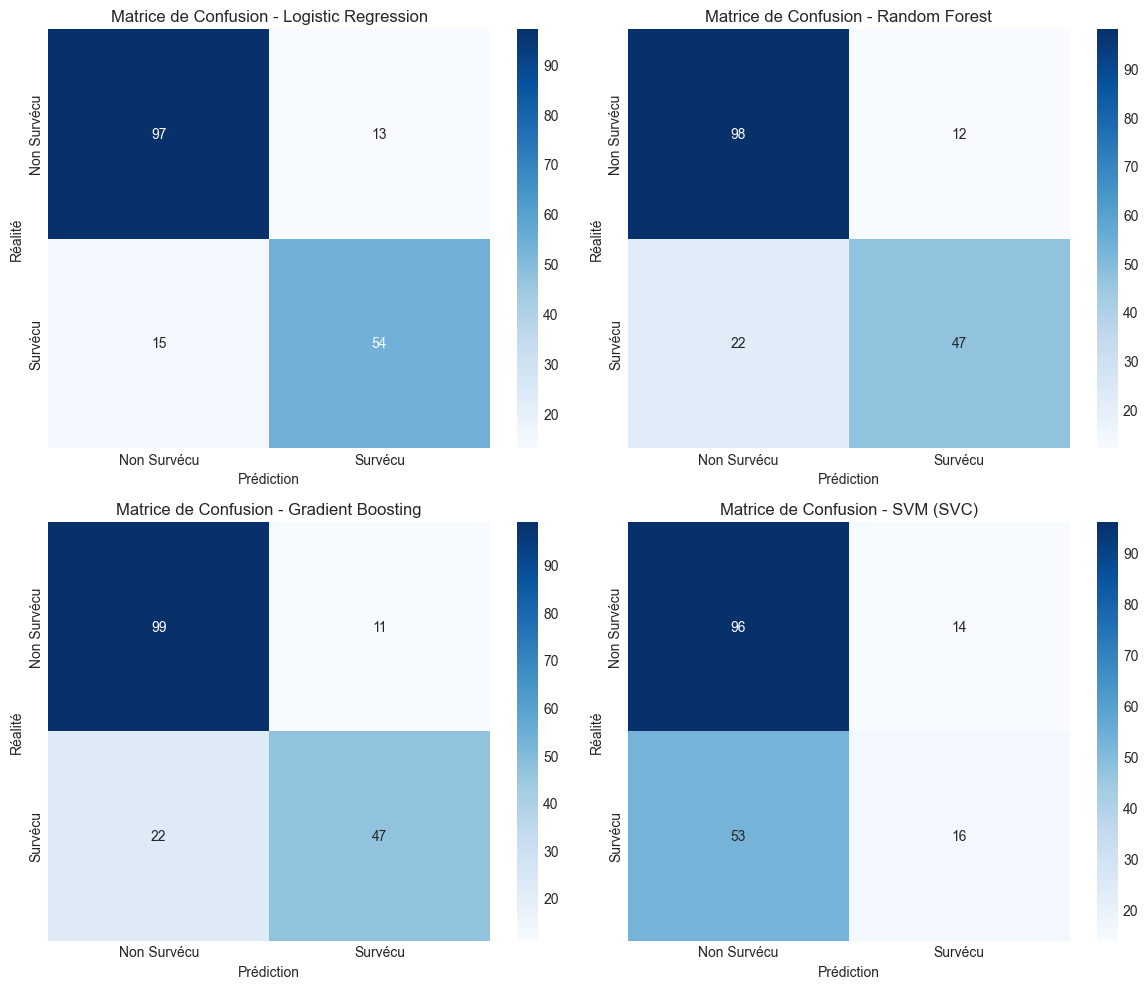


✓ Figure sauvegardée: reports/figures/confusion_matrices.png


In [19]:
# Matrices de confusion pour tous les modèles
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non Survécu', 'Survécu'],
                yticklabels=['Non Survécu', 'Survécu'])
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Réalité')
    axes[idx].set_title(f'Matrice de Confusion - {name}')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardée: reports/figures/confusion_matrices.png")

## 11. Sélection du Meilleur Modèle

Analysons les résultats pour déterminer le meilleur modèle à transmettre à la **Personne 4** pour le tuning des hyperparamètres.

In [20]:
# Identification du meilleur modèle selon F1-Score
best_idx = test_results_df['f1'].idxmax()
best_model_name = test_results_df.loc[best_idx, 'model']
best_f1 = test_results_df.loc[best_idx, 'f1']

print("="*70)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("="*70)

# Tableau récapitulatif trié par F1-Score
print("\nClassement des modèles (par F1-Score):")
print("-"*50)
ranking = test_results_df.sort_values('f1', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1  # Commencer à 1
ranking['rank'] = ['1', '2', '3', '4'][:len(ranking)]
print(ranking[['rank', 'model', 'f1', 'roc_auc']].to_string(index=False))

print(f"\n{'='*70}")
print(f" MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score sur test set: {best_f1:.4f}")
print(f"{'='*70}")

SÉLECTION DU MEILLEUR MODÈLE

Classement des modèles (par F1-Score):
--------------------------------------------------
rank               model       f1  roc_auc
   1 Logistic Regression 0.794118 0.870487
   2   Gradient Boosting 0.740157 0.844401
   3       Random Forest 0.734375 0.854216
   4           SVM (SVC) 0.323232 0.711924

 MEILLEUR MODÈLE: Logistic Regression
   F1-Score sur test set: 0.7941


In [21]:
# Rapport de classification détaillé pour le meilleur modèle
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Rapport de classification détaillé - {best_model_name}")
print("="*60)
print(classification_report(y_test, y_pred_best, 
                           target_names=['Non Survécu (0)', 'Survécu (1)']))

Rapport de classification détaillé - Logistic Regression
                 precision    recall  f1-score   support

Non Survécu (0)       0.87      0.88      0.87       110
    Survécu (1)       0.81      0.78      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179



## 12. Importance des Features (Random Forest)

Le Random Forest permet d'extraire l'importance de chaque feature dans la prédiction.

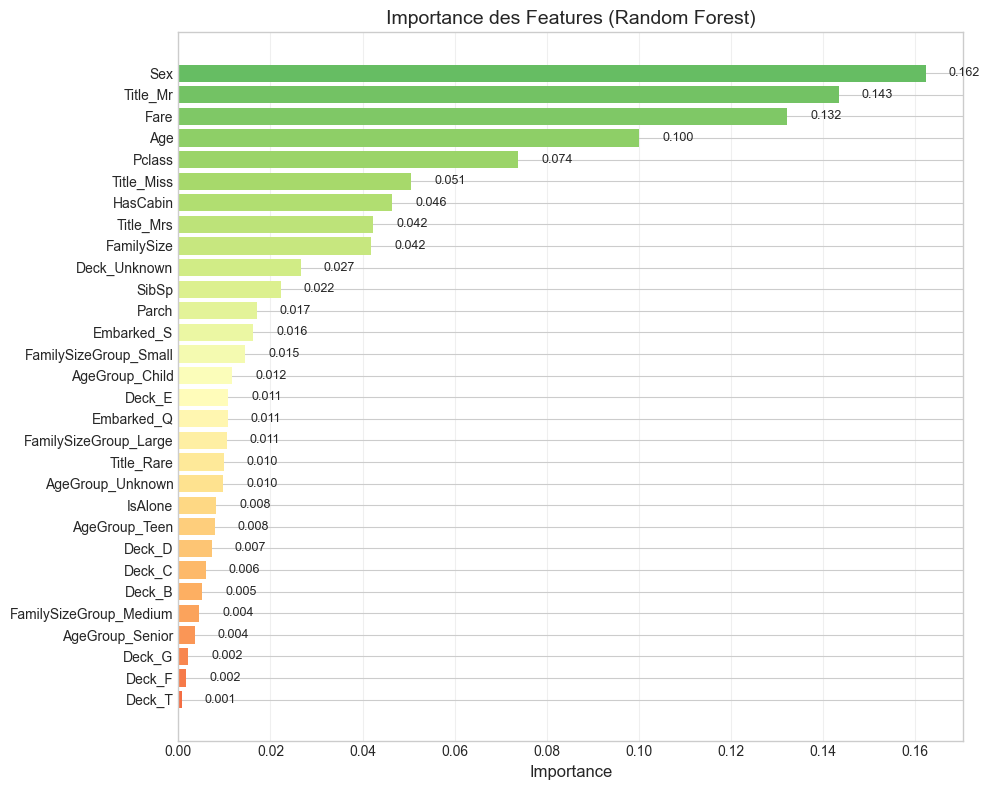


✓ Figure sauvegardée: reports/figures/feature_importance.png

🔝 Top 5 features les plus importantes:
   Sex: 0.1622
   Title_Mr: 0.1434
   Fare: 0.1322
   Age: 0.1001
   Pclass: 0.0738


In [22]:
# Importance des features avec Random Forest
rf_model = models['Random Forest']

# Extraire l'importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_importance)))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Importance des Features (Random Forest)', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardée: reports/figures/feature_importance.png")

# Top 5 features les plus importantes
print("\n🔝 Top 5 features les plus importantes:")
for idx, row in feature_importance.tail(5).iloc[::-1].iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

## 13. Sauvegarde des Modèles et Résultats

Sauvegardons les modèles entraînés et les résultats

In [23]:
import joblib
import os

# Créer le dossier models s'il n'existe pas
os.makedirs('../models', exist_ok=True)

# Sauvegarder tous les modèles
for name, model in models.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.joblib'
    filepath = f'../models/{filename}'
    joblib.dump(model, filepath)
    print(f"✓ Modèle sauvegardé: {filepath}")

# Sauvegarder les résultats
test_results_df.to_csv('../models/model_results.csv', index=False)
print(f"\n✓ Résultats sauvegardés: ../models/model_results.csv")

# Sauvegarder les données de train/test pour la Personne 4
import pickle
data_dict = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': list(X_train.columns)
}
with open('../models/train_test_data.pkl', 'wb') as f:
    pickle.dump(data_dict, f)
print(f"✓ Données train/test sauvegardées: ../models/train_test_data.pkl")

✓ Modèle sauvegardé: ../models/logistic_regression.joblib
✓ Modèle sauvegardé: ../models/random_forest.joblib
✓ Modèle sauvegardé: ../models/gradient_boosting.joblib
✓ Modèle sauvegardé: ../models/svm_svc.joblib

✓ Résultats sauvegardés: ../models/model_results.csv
✓ Données train/test sauvegardées: ../models/train_test_data.pkl
